# 🗑️ Image Classification using Transfer Learning
**Deteksi Jenis Sampah di Sekitar Kampus**

- **Week 13**: Transfer Learning dengan EfficientNetB0 (pre-trained ImageNet)
- **Week 14**: Deteksi Overfitting & Penanganannya

Dataset: [Trash Type Image Dataset](https://www.kaggle.com/datasets/farzadnekouei/trash-type-image-dataset)  
Kelas: `cardboard`, `glass`, `metal`, `paper`, `plastic`, `trash`

---
### Mengapa Transfer Learning?
Deep learning tradisional membutuhkan jutaan data, waktu training berminggu-minggu, dan GPU mahal.
Transfer Learning memungkinkan kita memanfaatkan model yang sudah dilatih (EfficientNetB0 pada ImageNet dengan 1.2 juta gambar) untuk mengatasi keterbatasan ini.

**Strategi yang digunakan: Fine-Tuning (2 tahap)**
1. **Tahap 1** — Freeze semua layer base model, hanya latih classifier baru (Fixed Feature Extractor)
2. **Tahap 2** — Unfreeze sebagian layer atas, fine-tune dengan learning rate kecil

## 📦 1. Install & Import Library

In [1]:
!pip install tensorflow matplotlib seaborn scikit-learn pillow


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


In [2]:
import os
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'  # Matikan warning oneDNN
import tensorflow as tf
# Verifikasi GPU
gpus = tf.config.list_physical_devices('GPU')
print(f"GPU tersedia: {gpus}")

# Aktifkan memory growth (cegah TF ambil semua VRAM sekaligus)
for gpu in gpus:
    tf.config.experimental.set_memory_growth(gpu, True)
print("GPU siap digunakan!")

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

from sklearn.metrics import classification_report, confusion_matrix

# Suppress verbose TF logs
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

print(f"TensorFlow version : {tf.__version__}")
print(f"GPU tersedia       : {tf.config.list_physical_devices('GPU')}")
print(f"CPU threads        : {os.cpu_count()}")

I0000 00:00:1782996021.529602    9882 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


GPU tersedia: []
GPU siap digunakan!
TensorFlow version : 2.21.0
GPU tersedia       : []
CPU threads        : 12


W0000 00:00:1782996025.873238    9882 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


## 📁 2. Konfigurasi

In [3]:
# =============================================
# SESUAIKAN PATH INI DENGAN LOKASI DATASET
# =============================================
DATASET_DIR = './archive/TrashType_Image_Dataset'

# EfficientNetB0 default input size
IMG_SIZE      = (224, 224)
BATCH_SIZE    = 32
SEED          = 42
VAL_SPLIT     = 0.15

# Tahap 1: Feature Extraction
EPOCHS_STAGE1 = 15
LR_STAGE1     = 1e-3

# Tahap 2: Fine-Tuning
EPOCHS_STAGE2 = 20
LR_STAGE2     = 1e-4   # Learning rate lebih kecil saat fine-tuning
FINE_TUNE_AT  = 200    # Unfreeze dari layer ke-200 (dari ~237 total)

CLASS_NAMES = sorted(os.listdir(DATASET_DIR))
NUM_CLASSES = len(CLASS_NAMES)
print(f"Kelas ({NUM_CLASSES}): {CLASS_NAMES}")

Kelas (6): ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']


## 🔍 3. Eksplorasi Dataset (EDA)

Total gambar: 2527
  cardboard   :  403 (15.9%)
  glass       :  501 (19.8%)
  metal       :  410 (16.2%)
  paper       :  594 (23.5%)
  plastic     :  482 (19.1%)
  trash       :  137 (5.4%)

⚠️  Imbalance ratio: paper(594) / trash(137) = 4.3x
   → Dataset cukup imbalanced, akan ditangani dengan class_weight


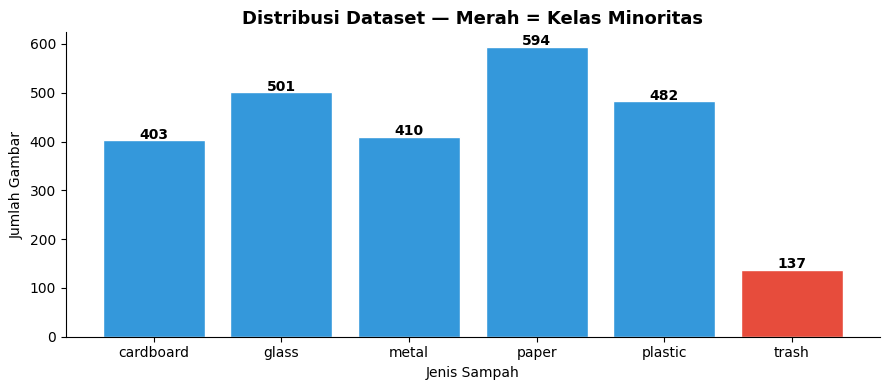

In [4]:
# Distribusi gambar per kelas
class_counts = {}
for cls in CLASS_NAMES:
    cls_path = os.path.join(DATASET_DIR, cls)
    imgs = [f for f in os.listdir(cls_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    class_counts[cls] = len(imgs)

total = sum(class_counts.values())
print(f"Total gambar: {total}")
for cls, count in class_counts.items():
    print(f"  {cls:12s}: {count:4d} ({count/total*100:.1f}%)")

# Cek imbalance: kelas 'trash' hanya 137 vs 'paper' 594
min_cls = min(class_counts, key=class_counts.get)
max_cls = max(class_counts, key=class_counts.get)
ratio = class_counts[max_cls] / class_counts[min_cls]
print(f"\n⚠️  Imbalance ratio: {max_cls}({class_counts[max_cls]}) / {min_cls}({class_counts[min_cls]}) = {ratio:.1f}x")
if ratio > 3:
    print("   → Dataset cukup imbalanced, akan ditangani dengan class_weight")

# Plot
fig, ax = plt.subplots(figsize=(9, 4))
colors = ['#E74C3C' if c == min_cls else '#3498DB' for c in class_counts.keys()]
bars = ax.bar(class_counts.keys(), class_counts.values(), color=colors, edgecolor='white')
for bar, count in zip(bars, class_counts.values()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3, str(count),
            ha='center', fontweight='bold', fontsize=10)
ax.set_title('Distribusi Dataset — Merah = Kelas Minoritas', fontsize=13, fontweight='bold')
ax.set_xlabel('Jenis Sampah'); ax.set_ylabel('Jumlah Gambar')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('tl_distribusi_kelas.png', dpi=150, bbox_inches='tight')
plt.show()

## ⚙️ 4. Preprocessing & Data Augmentation

Augmentasi lebih agresif diterapkan pada kelas minoritas (`trash`) untuk mengatasi imbalance.

In [5]:
# EfficientNetB0 sudah include preprocessing internalnya (rescale ke [-1,1])
# Jadi kita TIDAK perlu rescale manual

train_datagen = ImageDataGenerator(
    preprocessing_function=tf.keras.applications.efficientnet.preprocess_input,
    validation_split=VAL_SPLIT,
    # Augmentasi untuk mencegah overfitting
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.15,
    zoom_range=0.2,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2],
    fill_mode='nearest'
)

val_datagen = ImageDataGenerator(
    preprocessing_function=tf.keras.applications.efficientnet.preprocess_input,
)

train_gen = train_datagen.flow_from_directory(
    DATASET_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    seed=SEED,
    shuffle=True
)

val_gen = train_datagen.flow_from_directory(
    DATASET_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    seed=SEED,
    shuffle=False
)

print(f"Training samples  : {train_gen.samples}")
print(f"Validation samples: {val_gen.samples}")
print(f"Class indices     : {train_gen.class_indices}")

Found 2150 images belonging to 6 classes.
Found 377 images belonging to 6 classes.
Training samples  : 2150
Validation samples: 377
Class indices     : {'cardboard': 0, 'glass': 1, 'metal': 2, 'paper': 3, 'plastic': 4, 'trash': 5}


In [6]:
# Hitung class_weight untuk menangani imbalance
from sklearn.utils.class_weight import compute_class_weight

class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_gen.classes),
    y=train_gen.classes
)
class_weights = dict(enumerate(class_weights_array))

print("Class weights (untuk mengatasi imbalance):")
for idx, (cls, w) in enumerate(zip(CLASS_NAMES, class_weights_array)):
    print(f"  {cls:12s}: {w:.4f}")

Class weights (untuk mengatasi imbalance):
  cardboard   : 1.0447
  glass       : 0.8412
  metal       : 1.0267
  paper       : 0.7096
  plastic     : 0.8740
  trash       : 3.0627


## 🏗️ 5. Arsitektur Model — Transfer Learning (EfficientNetB0)

### Strategi: Fixed Feature Extractor → Fine-Tuning

```
Input (224×224×3)
  ↓
EfficientNetB0 [PRE-TRAINED, ImageNet] ← di-freeze dulu
  ↓
GlobalAveragePooling2D
  ↓
BatchNormalization
  ↓
Dense(256) → ReLU → Dropout(0.5)
  ↓
Dense(6, Softmax) ← hanya ini yang dilatih di Tahap 1
```

In [7]:
def build_transfer_model(num_classes, input_shape=(224, 224, 3)):
    """
    Transfer Learning dengan EfficientNetB0.
    Base model di-freeze untuk Tahap 1 (Fixed Feature Extractor).
    """
    # Load EfficientNetB0 pre-trained dari ImageNet
    # include_top=False → hapus classifier asli (1000 kelas ImageNet)
    base_model = EfficientNetB0(
        weights='imagenet',
        include_top=False,
        input_shape=input_shape
    )

    # TAHAP 1: Freeze semua layer base model
    base_model.trainable = False

    # Bangun model baru di atas base
    inputs = keras.Input(shape=input_shape)
    x = base_model(inputs, training=False)  # training=False penting saat frozen

    # Classifier baru (Head)
    x = layers.GlobalAveragePooling2D(name='gap')(x)
    x = layers.BatchNormalization(name='bn_head')(x)
    x = layers.Dense(256, activation='relu', name='fc_256')(x)
    x = layers.Dropout(0.5, name='dropout_head')(x)           # Anti-overfitting
    outputs = layers.Dense(num_classes, activation='softmax', name='predictions')(x)

    model = keras.Model(inputs, outputs, name='EfficientNetB0_TrashClassifier')
    return model, base_model


model, base_model = build_transfer_model(NUM_CLASSES)

# Ringkasan
total_params     = model.count_params()
trainable_params = sum([np.prod(v.shape) for v in model.trainable_weights])
frozen_params    = total_params - trainable_params

print(f"Total parameter    : {total_params:,}")
print(f"Trainable (Tahap 1): {trainable_params:,} ({trainable_params/total_params*100:.1f}%)")
print(f"Frozen (base model): {frozen_params:,} ({frozen_params/total_params*100:.1f}%)")
print(f"Base model layers  : {len(base_model.layers)}")

Total parameter    : 4,384,169
Trainable (Tahap 1): 332,038 (7.6%)
Frozen (base model): 4,052,131 (92.4%)
Base model layers  : 238


## 🎯 6. Tahap 1 — Feature Extraction (Base Model Frozen)

In [8]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LR_STAGE1),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

callbacks_stage1 = [
    EarlyStopping(
        monitor='val_accuracy', patience=5,
        restore_best_weights=True, verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss', factor=0.5,
        patience=3, min_lr=1e-6, verbose=1
    ),
    ModelCheckpoint(
        'best_model_stage1.keras', monitor='val_accuracy',
        save_best_only=True, verbose=1
    )
]

print("=" * 50)
print("TAHAP 1: Fixed Feature Extraction")
print("Base EfficientNetB0 = FROZEN")
print(f"Training only: head classifier ({trainable_params:,} params)")
print("=" * 50)

history_stage1 = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS_STAGE1,
    callbacks=callbacks_stage1,
    class_weight=class_weights,  # Tangani imbalance
    verbose=1
)

TAHAP 1: Fixed Feature Extraction
Base EfficientNetB0 = FROZEN
Training only: head classifier (332,038 params)
Epoch 1/15


I0000 00:00:1782996027.866846    9882 generator_dataset_op.cc:213] Memory patch applied: M_TRIM_THRESHOLD=128 kb was set.


68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 825ms/step - accuracy: 0.5321 - loss: 1.5390
Epoch 1: val_accuracy improved from None to 0.79841, saving model to best_model_stage1.keras

Epoch 1: finished saving model to best_model_stage1.keras
68/68 ━━━━━━━━━━━━━━━━━━━━ 73s 1s/step - accuracy: 0.6572 - loss: 1.1282 - val_accuracy: 0.7984 - val_loss: 0.6147 - learning_rate: 0.0010
Epoch 2/15
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 773ms/step - accuracy: 0.8033 - loss: 0.5638
Epoch 2: val_accuracy improved from 0.79841 to 0.81698, saving model to best_model_stage1.keras

Epoch 2: finished saving model to best_model_stage1.keras
68/68 ━━━━━━━━━━━━━━━━━━━━ 62s 921ms/step - accuracy: 0.8079 - loss: 0.5558 - val_accuracy: 0.8170 - val_loss: 0.5360 - learning_rate: 0.0010
Epoch 3/15
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 792ms/step - accuracy: 0.8467 - loss: 0.4474
Epoch 3: val_accuracy improved from 0.81698 to 0.84615, saving model to best_model_stage1.keras

Epoch 3: finished saving model to best_model_stage1.keras
68/68 ━━━━

## 🔬 7. Tahap 2 — Fine-Tuning (Unfreeze Sebagian Layer)

In [9]:
# Unfreeze layer-layer terakhir base model (ab layer FINE_TUNE_AT ke atas)
base_model.trainable = True

# Freeze layer-layer awal (fitur umum: tepi, garis, tekstur)
# Hanya latih layer atas (fitur spesifik: bentuk objek)
for layer in base_model.layers[:FINE_TUNE_AT]:
    layer.trainable = False

trainable_ft = sum([np.prod(v.shape) for v in model.trainable_weights])
print(f"Layer total di base model : {len(base_model.layers)}")
print(f"Layer yang di-freeze      : {FINE_TUNE_AT}")
print(f"Layer yang di-unfreeze    : {len(base_model.layers) - FINE_TUNE_AT}")
print(f"Trainable params (Tahap 2): {trainable_ft:,}")

# Compile ulang dengan learning rate lebih kecil
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LR_STAGE2),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

callbacks_stage2 = [
    EarlyStopping(
        monitor='val_accuracy', patience=7,
        restore_best_weights=True, verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss', factor=0.5,
        patience=3, min_lr=1e-7, verbose=1
    ),
    ModelCheckpoint(
        'best_model_stage2.keras', monitor='val_accuracy',
        save_best_only=True, verbose=1
    )
]

print("\n" + "=" * 50)
print("TAHAP 2: Fine-Tuning")
print(f"Unfreeze dari layer {FINE_TUNE_AT} ke atas")
print(f"Learning rate dikecilkan: {LR_STAGE2} (dari {LR_STAGE1})")
print("=" * 50)

history_stage2 = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS_STAGE2,
    callbacks=callbacks_stage2,
    class_weight=class_weights,
    verbose=1
)

Layer total di base model : 238
Layer yang di-freeze      : 200
Layer yang di-unfreeze    : 38
Trainable params (Tahap 2): 2,382,742

TAHAP 2: Fine-Tuning
Unfreeze dari layer 200 ke atas
Learning rate dikecilkan: 0.0001 (dari 0.001)
Epoch 1/20
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 953ms/step - accuracy: 0.8466 - loss: 0.4648
Epoch 1: val_accuracy improved from None to 0.87003, saving model to best_model_stage2.keras

Epoch 1: finished saving model to best_model_stage2.keras
68/68 ━━━━━━━━━━━━━━━━━━━━ 84s 1s/step - accuracy: 0.8530 - loss: 0.4205 - val_accuracy: 0.8700 - val_loss: 0.5403 - learning_rate: 1.0000e-04
Epoch 2/20
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 964ms/step - accuracy: 0.9012 - loss: 0.2802
Epoch 2: val_accuracy did not improve from 0.87003
68/68 ━━━━━━━━━━━━━━━━━━━━ 75s 1s/step - accuracy: 0.8972 - loss: 0.2720 - val_accuracy: 0.8568 - val_loss: 0.5848 - learning_rate: 1.0000e-04
Epoch 3/20
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9257 - loss: 0.2221   
Epoch 3: val_accurac

## 📈 8. Visualisasi Training History (Gabungan Tahap 1 + 2)

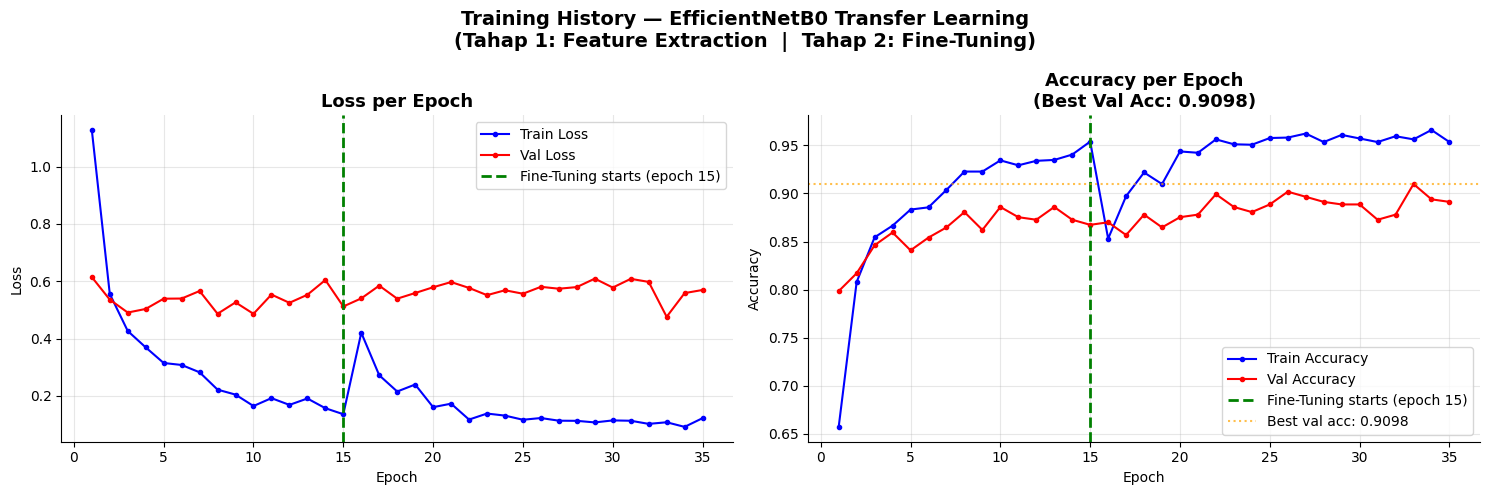

In [10]:
def plot_combined_history(h1, h2):
    """
    Plot training history untuk kedua tahap.
    Menampilkan garis vertikal sebagai batas antara Tahap 1 dan Tahap 2.
    """
    acc      = h1.history['accuracy']      + h2.history['accuracy']
    val_acc  = h1.history['val_accuracy']  + h2.history['val_accuracy']
    loss     = h1.history['loss']          + h2.history['loss']
    val_loss = h1.history['val_loss']      + h2.history['val_loss']
    ep1      = len(h1.history['accuracy'])  # Batas epoch Tahap 1
    total_ep = len(acc)

    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    epochs = range(1, total_ep + 1)

    # Loss
    axes[0].plot(epochs, loss,     'b-o', label='Train Loss',      markersize=3)
    axes[0].plot(epochs, val_loss, 'r-o', label='Val Loss',        markersize=3)
    axes[0].axvline(ep1, color='green', linestyle='--', linewidth=2, label=f'Fine-Tuning starts (epoch {ep1})')
    axes[0].set_title('Loss per Epoch', fontsize=13, fontweight='bold')
    axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
    axes[0].legend(); axes[0].grid(alpha=0.3)
    axes[0].spines[['top', 'right']].set_visible(False)

    # Accuracy
    axes[1].plot(epochs, acc,     'b-o', label='Train Accuracy',  markersize=3)
    axes[1].plot(epochs, val_acc, 'r-o', label='Val Accuracy',    markersize=3)
    axes[1].axvline(ep1, color='green', linestyle='--', linewidth=2, label=f'Fine-Tuning starts (epoch {ep1})')
    best_val = max(val_acc)
    best_ep  = val_acc.index(best_val) + 1
    axes[1].axhline(best_val, color='orange', linestyle=':', alpha=0.7, label=f'Best val acc: {best_val:.4f}')
    axes[1].set_title(f'Accuracy per Epoch\n(Best Val Acc: {best_val:.4f})', fontsize=13, fontweight='bold')
    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
    axes[1].legend(); axes[1].grid(alpha=0.3)
    axes[1].spines[['top', 'right']].set_visible(False)

    plt.suptitle('Training History — EfficientNetB0 Transfer Learning\n(Tahap 1: Feature Extraction  |  Tahap 2: Fine-Tuning)',
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('tl_training_history.png', dpi=150, bbox_inches='tight')
    plt.show()
    return acc, val_acc, loss, val_loss

acc, val_acc, loss, val_loss = plot_combined_history(history_stage1, history_stage2)

## ⚠️ 9. Deteksi Overfitting (Week 14)

**Definisi dari materi:**
- **Overfitting** = training accuracy sangat tinggi tapi validation accuracy jauh lebih rendah (gap besar)
- **Underfitting** = keduanya sama-sama rendah
- **Just Right** = gap kecil (normal)

In [11]:
def detect_overfitting(acc, val_acc, loss, val_loss, threshold_gap=0.10):
    """
    Deteksi overfitting berdasarkan gap antara train dan val accuracy.
    threshold_gap = 0.10 → gap > 10% = overfitting
    """
    final_train_acc = acc[-1]
    final_val_acc   = val_acc[-1]
    best_val_acc    = max(val_acc)
    final_train_loss = loss[-1]
    final_val_loss   = val_loss[-1]
    gap_acc          = final_train_acc - final_val_acc

    print("=" * 55)
    print("   WEEK 14 — DIAGNOSA OVERFITTING")
    print("=" * 55)
    print(f"  Train Accuracy (akhir) : {final_train_acc*100:.2f}%")
    print(f"  Val   Accuracy (akhir) : {final_val_acc*100:.2f}%")
    print(f"  Best  Val Accuracy     : {best_val_acc*100:.2f}%")
    print(f"  Train Loss (akhir)     : {final_train_loss:.4f}")
    print(f"  Val   Loss (akhir)     : {final_val_loss:.4f}")
    print(f"  Gap Accuracy           : {gap_acc*100:.2f}%")
    print("-" * 55)

    # Diagnosis
    if final_train_acc < 0.70 and final_val_acc < 0.70:
        status = "UNDERFITTING"
        emoji  = "📉"
        detail = "Kedua akurasi rendah → model terlalu sederhana / training kurang"
    elif gap_acc > threshold_gap:
        status = "OVERFITTING"
        emoji  = "🔴"
        detail = f"Gap {gap_acc*100:.1f}% > {threshold_gap*100:.0f}% → model hafal data training"
    else:
        status = "JUST RIGHT (Normal)"
        emoji  = "✅"
        detail = f"Gap {gap_acc*100:.1f}% ≤ {threshold_gap*100:.0f}% → model generalisasi baik"

    print(f"  {emoji} Diagnosis: {status}")
    print(f"     {detail}")
    print("=" * 55)

    # Tabel referensi (dari materi Week 14)
    print("\nReferensi (dari materi Week 14):")
    print(f"  {'Kondisi':15s} | {'Train Acc':12s} | {'Val Acc':10s} | Diagnosis")
    print(f"  {'-'*15} | {'-'*12} | {'-'*10} | {'-'*20}")
    print(f"  {'Underfitting':15s} | {'60%':12s} | {'65%':10s} | Sama-sama rendah")
    print(f"  {'Just Right':15s} | {'85%':12s} | {'82%':10s} | Gap kecil (normal)")
    print(f"  {'Overfitting':15s} | {'99%':12s} | {'65%':10s} | Gap besar!")
    print(f"  {'MODEL INI':15s} | {final_train_acc*100:.0f}%{'':9s} | {final_val_acc*100:.0f}%{'':7s} | {status}")

    return status

overfitting_status = detect_overfitting(acc, val_acc, loss, val_loss)

   WEEK 14 — DIAGNOSA OVERFITTING
  Train Accuracy (akhir) : 95.35%
  Val   Accuracy (akhir) : 89.12%
  Best  Val Accuracy     : 90.98%
  Train Loss (akhir)     : 0.1223
  Val   Loss (akhir)     : 0.5697
  Gap Accuracy           : 6.22%
-------------------------------------------------------
  ✅ Diagnosis: JUST RIGHT (Normal)
     Gap 6.2% ≤ 10% → model generalisasi baik

Referensi (dari materi Week 14):
  Kondisi         | Train Acc    | Val Acc    | Diagnosis
  --------------- | ------------ | ---------- | --------------------
  Underfitting    | 60%          | 65%        | Sama-sama rendah
  Just Right      | 85%          | 82%        | Gap kecil (normal)
  Overfitting     | 99%          | 65%        | Gap besar!
  MODEL INI       | 95%          | 89%        | JUST RIGHT (Normal)


## 🛡️ 10. Penanganan Overfitting (jika terjadi)

Teknik yang digunakan sesuai materi Week 14:
- ✅ **Dropout** — sudah diterapkan di head classifier (rate 0.5)
- ✅ **Batch Normalization** — sudah diterapkan di head
- ✅ **Early Stopping** — berhenti saat val_accuracy tidak naik
- ✅ **Data Augmentation** — rotasi, flip, zoom, brightness
- ✅ **Class Weights** — menangani data imbalance
- ✅ **ReduceLROnPlateau** — kurangi LR saat stagnan
- ✅ **Fine-tuning bertahap** — cegah catastrophic forgetting

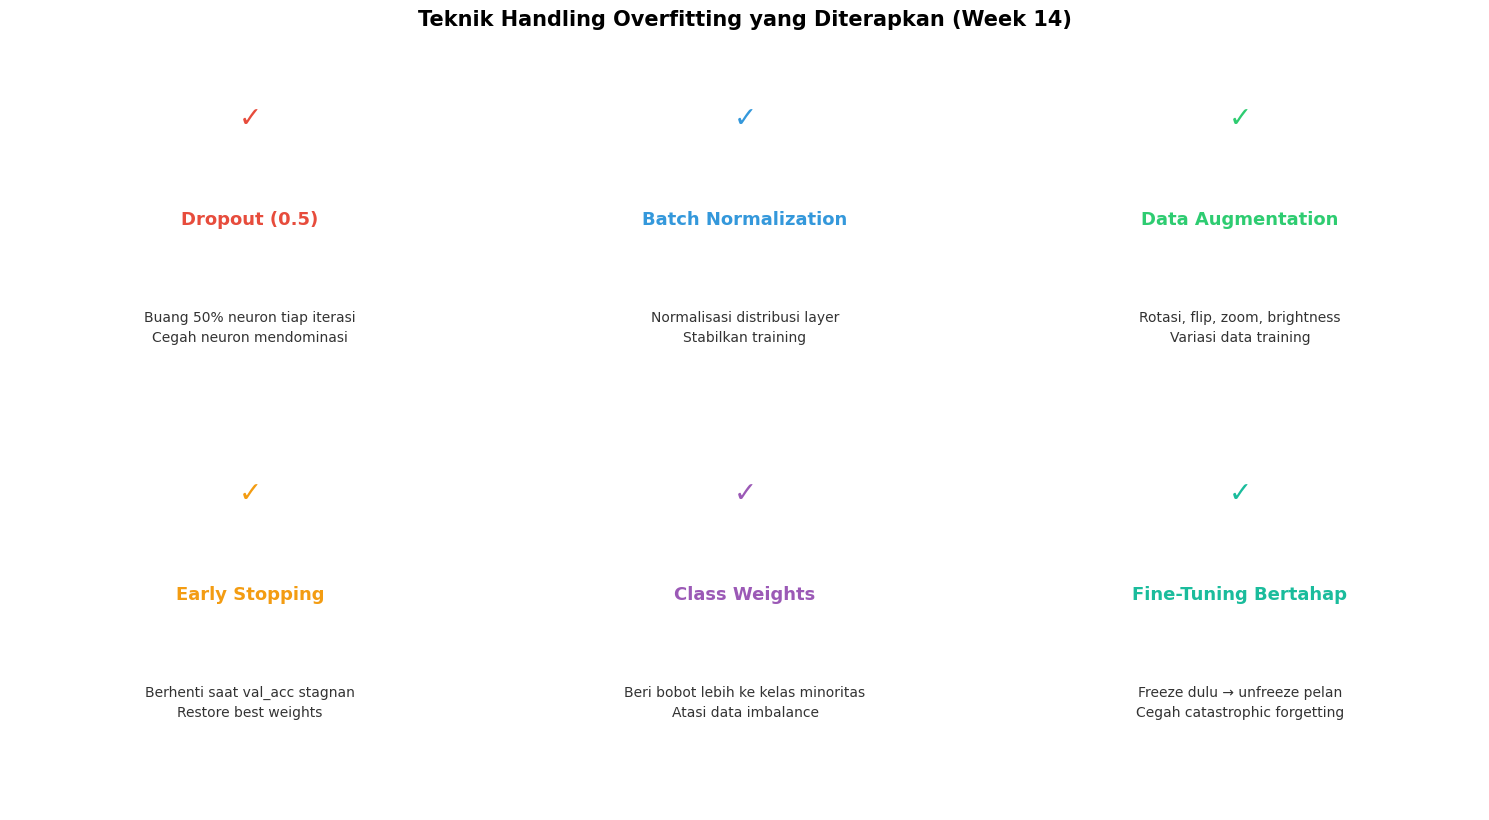

In [12]:
def plot_overfitting_techniques():
    """Visualisasi teknik anti-overfitting yang sudah diterapkan."""
    techniques = [
        ("Dropout (0.5)",         "Buang 50% neuron tiap iterasi\nCegah neuron mendominasi",    "#E74C3C"),
        ("Batch Normalization",   "Normalisasi distribusi layer\nStabilkan training",             "#3498DB"),
        ("Data Augmentation",     "Rotasi, flip, zoom, brightness\nVariasi data training",        "#2ECC71"),
        ("Early Stopping",        "Berhenti saat val_acc stagnan\nRestore best weights",          "#F39C12"),
        ("Class Weights",         "Beri bobot lebih ke kelas minoritas\nAtasi data imbalance",   "#9B59B6"),
        ("Fine-Tuning Bertahap",  "Freeze dulu → unfreeze pelan\nCegah catastrophic forgetting", "#1ABC9C"),
    ]

    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    axes = axes.flatten()

    for i, (name, desc, color) in enumerate(techniques):
        axes[i].set_facecolor(color + '22')
        axes[i].text(0.5, 0.6, name, ha='center', va='center', fontsize=13,
                     fontweight='bold', color=color, transform=axes[i].transAxes)
        axes[i].text(0.5, 0.3, desc, ha='center', va='center', fontsize=10,
                     color='#333333', transform=axes[i].transAxes, linespacing=1.5)
        axes[i].text(0.5, 0.88, '✓', ha='center', va='center', fontsize=20,
                     color=color, transform=axes[i].transAxes, fontweight='bold')
        axes[i].axis('off')
        for spine in axes[i].spines.values():
            spine.set_edgecolor(color)
            spine.set_linewidth(2)
            spine.set_visible(True)

    plt.suptitle('Teknik Handling Overfitting yang Diterapkan (Week 14)',
                 fontsize=15, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig('tl_overfitting_techniques.png', dpi=150, bbox_inches='tight')
    plt.show()

plot_overfitting_techniques()

## 📊 11. Evaluasi Model

In [13]:
# Load best model dari Tahap 2
best_model = keras.models.load_model('best_model_stage2.keras')

val_loss_final, val_acc_final = best_model.evaluate(val_gen, verbose=1)
print(f"\nValidation Loss    : {val_loss_final:.4f}")
print(f"Validation Accuracy: {val_acc_final:.4f} ({val_acc_final*100:.2f}%)")

12/12 ━━━━━━━━━━━━━━━━━━━━ 13s 859ms/step - accuracy: 0.8912 - loss: 0.5280

Validation Loss    : 0.5280
Validation Accuracy: 0.8912 (89.12%)


In [14]:
# Prediksi
val_gen.reset()
y_pred_proba = best_model.predict(val_gen, verbose=1)
y_pred = np.argmax(y_pred_proba, axis=1)
y_true = val_gen.classes

print("\n=== Classification Report ===")
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES, digits=4))

12/12 ━━━━━━━━━━━━━━━━━━━━ 13s 954ms/step

=== Classification Report ===
              precision    recall  f1-score   support

   cardboard     0.9828    0.9500    0.9661        60
       glass     0.9342    0.9467    0.9404        75
       metal     0.8636    0.9344    0.8976        61
       paper     0.9167    0.8652    0.8902        89
     plastic     0.9661    0.7917    0.8702        72
       trash     0.5000    0.8500    0.6296        20

    accuracy                         0.8912       377
   macro avg     0.8606    0.8897    0.8657       377
weighted avg     0.9094    0.8912    0.8958       377



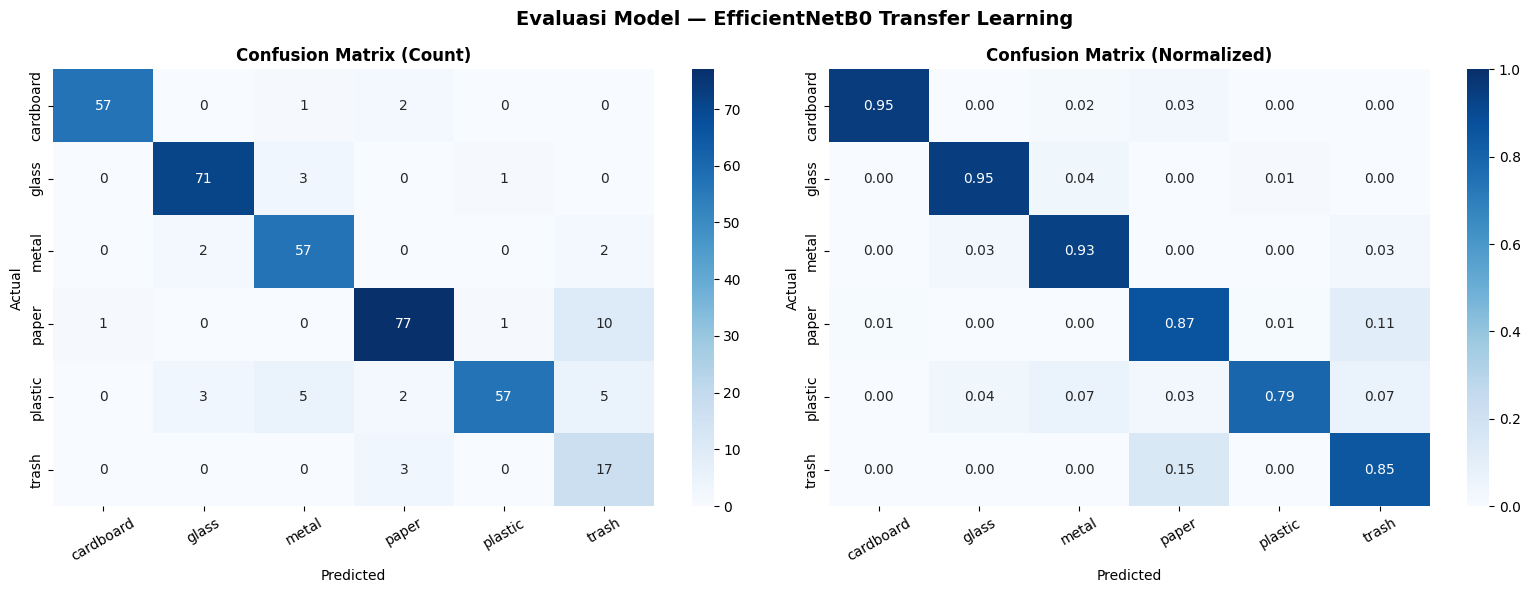

In [15]:
# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=axes[0])
axes[0].set_title('Confusion Matrix (Count)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('Actual')
axes[0].tick_params(axis='x', rotation=30)

sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=axes[1], vmin=0, vmax=1)
axes[1].set_title('Confusion Matrix (Normalized)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('Actual')
axes[1].tick_params(axis='x', rotation=30)

plt.suptitle('Evaluasi Model — EfficientNetB0 Transfer Learning', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('tl_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

## 🔮 12. Prediksi Gambar Baru

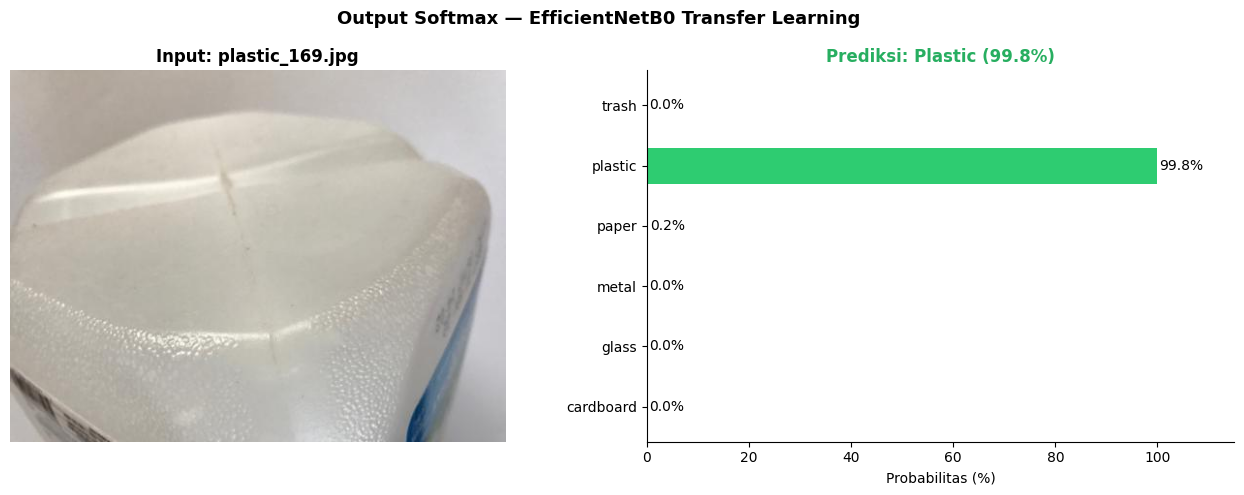

('plastic', np.float32(0.9982339))

In [16]:
def predict_image(model, img_path, class_names, img_size=(224, 224)):
    from PIL import Image as PILImage

    img = PILImage.open(img_path).convert('RGB').resize(img_size)
    img_array = np.array(img)
    img_array = tf.keras.applications.efficientnet.preprocess_input(img_array)
    img_array = np.expand_dims(img_array, axis=0)

    proba = model.predict(img_array, verbose=0)[0]
    pred_idx = np.argmax(proba)
    pred_class = class_names[pred_idx]
    confidence = proba[pred_idx]

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    axes[0].imshow(PILImage.open(img_path))
    axes[0].set_title(f'Input: {os.path.basename(img_path)}', fontweight='bold')
    axes[0].axis('off')

    colors_bar = ['#2ECC71' if i == pred_idx else '#BDC3C7' for i in range(len(class_names))]
    bars = axes[1].barh(class_names, proba * 100, color=colors_bar, height=0.6)
    for bar, p in zip(bars, proba):
        axes[1].text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
                     f'{p*100:.1f}%', va='center', fontsize=10)
    axes[1].set_xlim(0, 115)
    axes[1].set_xlabel('Probabilitas (%)')
    axes[1].set_title(f'Prediksi: {pred_class.capitalize()} ({confidence*100:.1f}%)',
                      fontsize=12, fontweight='bold', color='#27AE60')
    axes[1].spines[['top', 'right']].set_visible(False)

    plt.suptitle('Output Softmax — EfficientNetB0 Transfer Learning', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig('tl_prediksi_output.png', dpi=150, bbox_inches='tight')
    plt.show()
    return pred_class, confidence

# Test pada satu gambar
sample_cls = CLASS_NAMES[4]  # 'plastic'
sample_dir = os.path.join(DATASET_DIR, sample_cls)
sample_files = [f for f in os.listdir(sample_dir) if f.lower().endswith(('.jpg','.jpeg','.png'))]
test_img_path = os.path.join(sample_dir, sample_files[5])

predict_image(best_model, test_img_path, CLASS_NAMES, IMG_SIZE)

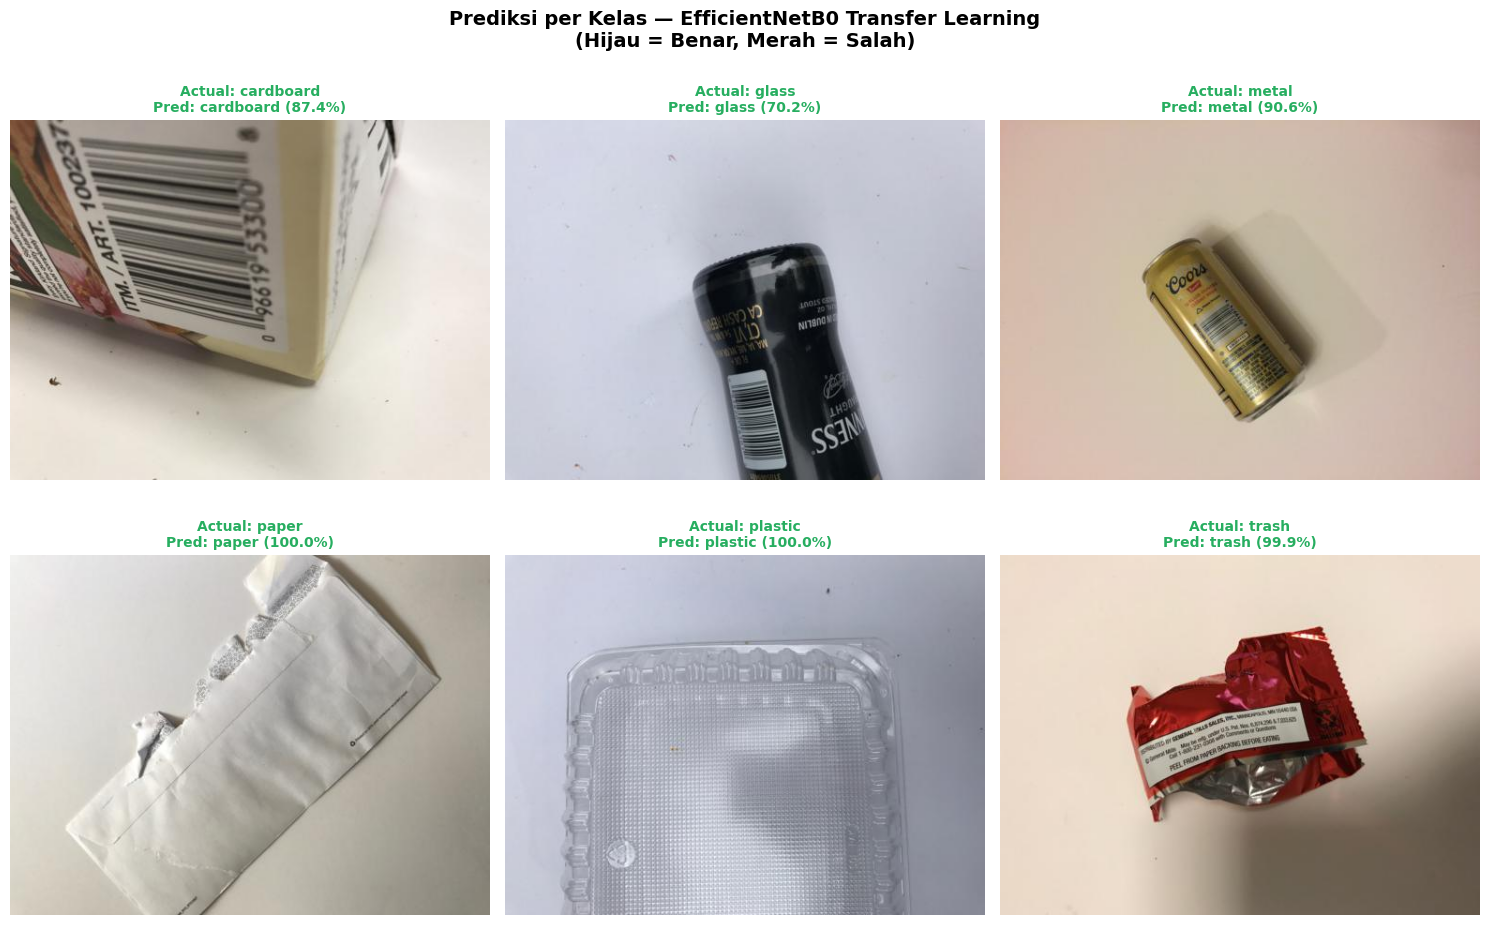

In [17]:
# Grid prediksi semua kelas
from PIL import Image as PILImage

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, cls in enumerate(CLASS_NAMES):
    cls_dir = os.path.join(DATASET_DIR, cls)
    files   = [f for f in os.listdir(cls_dir) if f.lower().endswith(('.jpg','.jpeg','.png'))]
    path    = os.path.join(cls_dir, files[10])

    img = PILImage.open(path).convert('RGB').resize(IMG_SIZE)
    arr = tf.keras.applications.efficientnet.preprocess_input(np.array(img))
    arr = np.expand_dims(arr, axis=0)
    proba = best_model.predict(arr, verbose=0)[0]
    pred_cls   = CLASS_NAMES[np.argmax(proba)]
    confidence = proba[np.argmax(proba)]

    axes[i].imshow(PILImage.open(path))
    color = '#27AE60' if pred_cls == cls else '#E74C3C'
    axes[i].set_title(
        f"Actual: {cls}\nPred: {pred_cls} ({confidence*100:.1f}%)",
        fontsize=10, fontweight='bold', color=color
    )
    axes[i].axis('off')

plt.suptitle('Prediksi per Kelas — EfficientNetB0 Transfer Learning\n(Hijau = Benar, Merah = Salah)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('tl_prediksi_grid.png', dpi=150, bbox_inches='tight')
plt.show()

## 🗺️ 13. Ringkasan Akhir

In [18]:
print("=" * 60)
print("   RINGKASAN — TRANSFER LEARNING & OVERFITTING HANDLING")
print("=" * 60)
print(f"  Model Base        : EfficientNetB0 (pre-trained ImageNet)")
print(f"  Dataset           : Trash Type ({NUM_CLASSES} kelas, {total} gambar)")
print(f"  Image Size        : {IMG_SIZE[0]}×{IMG_SIZE[1]} piksel")
print(f"  Val Accuracy      : {val_acc_final*100:.2f}%")
print(f"  Diagnosis         : {overfitting_status}")
print("-" * 60)
print("  TEKNIK ANTI-OVERFITTING YANG DITERAPKAN:")
techniques_applied = [
    "Dropout (rate=0.5) di head classifier",
    "Batch Normalization di head classifier",
    "Data Augmentation (rotasi, flip, zoom, brightness)",
    "Early Stopping (patience=7, restore best weights)",
    "ReduceLROnPlateau (factor=0.5, patience=3)",
    "Class Weights (balanced, tangani imbalance)",
    "Fine-Tuning Bertahap (freeze → unfreeze layer atas)",
]
for t in techniques_applied:
    print(f"  ✓ {t}")
print("=" * 60)

# Simpan model
best_model.save('EfficientNetB0_TrashClassifier_final.keras')
print("\n✅ Model disimpan: EfficientNetB0_TrashClassifier_final.keras")

   RINGKASAN — TRANSFER LEARNING & OVERFITTING HANDLING
  Model Base        : EfficientNetB0 (pre-trained ImageNet)
  Dataset           : Trash Type (6 kelas, 2527 gambar)
  Image Size        : 224×224 piksel
  Val Accuracy      : 89.12%
  Diagnosis         : JUST RIGHT (Normal)
------------------------------------------------------------
  TEKNIK ANTI-OVERFITTING YANG DITERAPKAN:
  ✓ Dropout (rate=0.5) di head classifier
  ✓ Batch Normalization di head classifier
  ✓ Data Augmentation (rotasi, flip, zoom, brightness)
  ✓ Early Stopping (patience=7, restore best weights)
  ✓ ReduceLROnPlateau (factor=0.5, patience=3)
  ✓ Class Weights (balanced, tangani imbalance)
  ✓ Fine-Tuning Bertahap (freeze → unfreeze layer atas)

✅ Model disimpan: EfficientNetB0_TrashClassifier_final.keras
